# 03 — Whisper on NPU vs sharing the iGPU (concurrency)

**The question:** on Panther Lake, is it better to run Whisper on the **NPU** while Gemma
has the iGPU to itself, or to run **both on the iGPU**? The honest answer depends on whether
the two workloads overlap in time. This notebook targets the *always-on* case — mic streaming
while the model is mid-answer — where the split should win.

Two configs, identical except where Whisper runs:

| | Config A — split | Config B — shared |
|---|---|---|
| Gemma (LLM/VLM) | iGPU, vLLM-XPU `:9000` | iGPU, vLLM-XPU `:9000` |
| Whisper (STT) | **NPU** `:9010` (`WHISPER_DEVICE=NPU`) | **iGPU** `:9010` (`WHISPER_DEVICE=GPU`) |

### How to run

1. Set `CONFIG_LABEL` below to match the Whisper device you brought up.
2. Run the notebook top to bottom. It warms up both paths (critical — NPU cold-compile is
   minutes and must not land in the window), drives LLM+STT concurrently for `DURATION_S`,
   and saves the run under `data/concurrency/`.
3. Stop Whisper, flip `WHISPER_DEVICE`, bring it back up, set `CONFIG_LABEL` to the other
   value, and run again.
4. The comparison cells at the bottom load **both** saved runs and draw the charts.

In [1]:
import sys, pathlib, json, time, urllib.request
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from bench import client, load, memprobe, plotting
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = pathlib.Path.cwd().parent

## Edit per run

Only `CONFIG_LABEL` changes between the two passes — keep everything else identical so the
two runs are comparable. Use the concurrency knobs to shape the load: `STT_WORKERS` is the
number of simultaneous audio streams (sweep 1 → 2 → 4 to show the shared config degrading
while the split holds); `STT_GAP_S=0` means always-on, back-to-back utterances.

In [ ]:
# ---- EDIT PER RUN ----
CONFIG_LABEL = 'shared (iGPU)'    # 'split (NPU)'  -> Whisper on NPU
                                  # 'shared (iGPU)' -> Whisper on iGPU

LLM_BASE_URL = 'http://127.0.0.1:9000/v1'
LLM_MODEL    = 'gemma-4-E4B-it'
LLM_PORT     = 9000
LLM_WORKERS  = 1                  # continuous back-to-back generation

STT_BASE_URL = 'http://127.0.0.1:9010/v1'
STT_MODEL    = 'whisper-large-v3-turbo-fp16-ov-npu'
STT_PORT     = 9010
STT_WORKERS  = 1                  # simultaneous audio streams (sweep 1/2/4)
STT_GAP_S    = 0.0                # 0 = always-on; >0 spaces a worker's utterances

AUDIO_MANIFEST = REPO_ROOT / 'data' / 'audio.json'
DURATION_S     = 120.0            # measured window per config
OUT_DIR        = REPO_ROOT / 'data' / 'concurrency'
# ----------------------

manifest = json.loads(AUDIO_MANIFEST.read_text())
clip = next(c for c in manifest['clips'] if c['id'] == manifest['default'])
AUDIO_PATH = REPO_ROOT / clip['path']
AUDIO_DUR_S = clip.get('duration_s')      # None -> RTF skipped, latency still shown
AUDIO_LANG = clip.get('language')
assert AUDIO_PATH.exists(), f'missing clip: {AUDIO_PATH}'
print(f'config   : {CONFIG_LABEL}')
print(f'clip     : {AUDIO_PATH.name}  dur={AUDIO_DUR_S}s  lang={AUDIO_LANG}')
print(f'load     : {LLM_WORKERS} LLM worker(s) + {STT_WORKERS} STT worker(s), gap={STT_GAP_S}s, window={DURATION_S}s')
if AUDIO_DUR_S is None:
    print('NOTE: duration_s is null -> RTF charts skipped; STT latency (s) still shown. Set it in data/audio.json.')

config   : split (NPU)
clip     : korean_audio.mp3  dur=Nones  lang=ko
load     : 1 LLM worker(s) + 1 STT worker(s), gap=0.0s, window=120.0s
NOTE: duration_s is null -> RTF charts skipped; STT latency (s) still shown. Set it in data/audio.json.


## Preflight: both servers up, both paths warmed

Finds the two server PIDs, checks liveness, and fires one throwaway request down each path.
The warmup is not optional: the **first** NPU transcription pays a multi-minute graph compile
(cached afterward under `~/.cache/ze_intel_npu_cache`), and the first iGPU call pays vLLM/OV
warmup — neither should be inside the measured window.

In [3]:
llm_pid = memprobe.find_server_pid(LLM_PORT)
stt_pid = memprobe.find_server_pid(STT_PORT)
print(f'LLM pid (:{LLM_PORT}) = {llm_pid}')
print(f'STT pid (:{STT_PORT}) = {stt_pid}')
assert llm_pid, f'no server on :{LLM_PORT} — bring up vLLM-XPU first'
assert stt_pid, f'no server on :{STT_PORT} — bring up Whisper first'

def _get(url, timeout=2.0):
    with urllib.request.urlopen(url, timeout=timeout) as r:
        return r.status, r.read(200)
try:
    print('STT /health:', _get(STT_BASE_URL.rstrip('/v1') + '/health'))
except Exception as e:
    print('STT /health check skipped:', e)

print('warming LLM path...')
client.warmup(base_url=LLM_BASE_URL, model=LLM_MODEL)
print('warming STT path (first NPU call compiles the graph — can take minutes)...')
t = time.perf_counter()
w = client.warmup_stt(base_url=STT_BASE_URL, model=STT_MODEL, audio_path=AUDIO_PATH,
                      audio_dur_s=AUDIO_DUR_S, language=AUDIO_LANG)
print(f'STT warmup done in {time.perf_counter()-t:.1f}s; sample text: {w.text[:60]!r}')

LLM pid (:9000) = 296725
STT pid (:9010) = 1
STT /health: (200, b'{"status":"ok","backend":"openvino","device":"NPU","model":"whisper-large-v3-turbo-fp16-ov-npu"}')
warming LLM path...
warming STT path (first NPU call compiles the graph — can take minutes)...
STT warmup done in 9.1s; sample text: '마이크 테스트 마이크 테스트 오경재로 갑니다. 잘 들으시나요?'


## Run the concurrent window

Drives both paths for `DURATION_S` while sampling RSS + iGPU-resident memory of **both**
server processes. The Whisper process's iGPU number is the budget story: ~0 in the split
config (it's on `/dev/accel`, holds no DRM fd) vs the model's footprint in the shared config
(carved from the same pool vLLM's KV cache wants).

In [4]:
prompts = json.loads((REPO_ROOT / 'data' / 'prompts.json').read_text())['text_only']

with memprobe.MemProbe(pid=llm_pid, interval_s=0.5) as llm_probe, \
     memprobe.MemProbe(pid=stt_pid, interval_s=0.5) as stt_probe:
    run = load.run_concurrent(
        label=CONFIG_LABEL, duration_s=DURATION_S,
        llm_base_url=LLM_BASE_URL, llm_model=LLM_MODEL,
        llm_prompts=prompts, llm_workers=LLM_WORKERS,
        stt_base_url=STT_BASE_URL, stt_model=STT_MODEL,
        stt_audio_path=AUDIO_PATH, stt_audio_dur_s=AUDIO_DUR_S,
        stt_language=AUDIO_LANG, stt_workers=STT_WORKERS, stt_gap_s=STT_GAP_S,
    )

def _peak_igpu(p):
    vals = [s.igpu_mb for s in p.samples if s.igpu_mb is not None]
    return max(vals) if vals else None
def _peak_rss(p):
    s = p.peak(); return s.rss_mb if s else None

run.meta['whisper_peak_igpu_mb'] = _peak_igpu(stt_probe)
run.meta['whisper_peak_rss_mb']  = _peak_rss(stt_probe)
run.meta['llm_peak_igpu_mb']     = _peak_igpu(llm_probe)
run.meta['llm_peak_rss_mb']      = _peak_rss(llm_probe)

slug = CONFIG_LABEL.split()[0].lower()   # 'split' | 'shared'
out = OUT_DIR / f'{slug}.json'
load.save_run(run, out)
print('saved', out)

saved /home/mvsk/git/vlm-notebooks/data/concurrency/split.json


In [5]:
s = load.summary(run)
for k, v in s.items():
    print(f'{k:24s} {v}')
print()
print(f"whisper iGPU resident: {run.meta['whisper_peak_igpu_mb']}")
print(f"whisper RSS          : {run.meta['whisper_peak_rss_mb']}")
if run.errors():
    print(f'\n{len(run.errors())} errors, e.g.:', run.errors()[0].error[:160])

label                    split (NPU)
duration_s               120.0
llm_calls                11
stt_calls                190
errors                   0
llm_tokens_per_s         9.0
audio_s_per_s            0.0
llm_decode_tps_p50       8.7
ttft_p95                 0.257
stt_latency_p50          0.678
stt_latency_p95          0.686
stt_latency_p99          0.689
stt_rtf_p50              nan
stt_rtf_p95              nan

whisper iGPU resident: 23034.421875
whisper RSS          : 21477.7265625


## Compare both configs

Run the cell below once you've captured **both** passes. It loads every run saved under
`data/concurrency/` and orders them split-first so colors are stable across the charts
(split = Intel blue, shared = red).

In [6]:
runs = []
for f in sorted(OUT_DIR.glob('*.json')):
    runs.append(load.load_run(f))
# split first, then shared, then anything else
order = {'split': 0, 'shared': 1}
runs.sort(key=lambda r: order.get(r.label.split()[0].lower(), 9))
print(f'{len(runs)} run(s):', [r.label for r in runs])
for r in runs:
    print(' ', load.summary(r))

1 run(s): ['split (NPU)']
  {'label': 'split (NPU)', 'duration_s': 120.0, 'llm_calls': 11, 'stt_calls': 190, 'errors': 0, 'llm_tokens_per_s': 9.0, 'audio_s_per_s': 0.0, 'llm_decode_tps_p50': 8.7, 'ttft_p95': 0.257, 'stt_latency_p50': 0.678, 'stt_latency_p95': 0.686, 'stt_latency_p99': 0.689, 'stt_rtf_p50': nan, 'stt_rtf_p95': nan}


### Headline — LLM throughput under concurrent STT

Gemma's instantaneous decode rate over wall-clock, with each transcription shaded. The split
config should hold flat through the bands; the shared config should sag inside them as the
iGPU time-slices between LLM decode and speech.

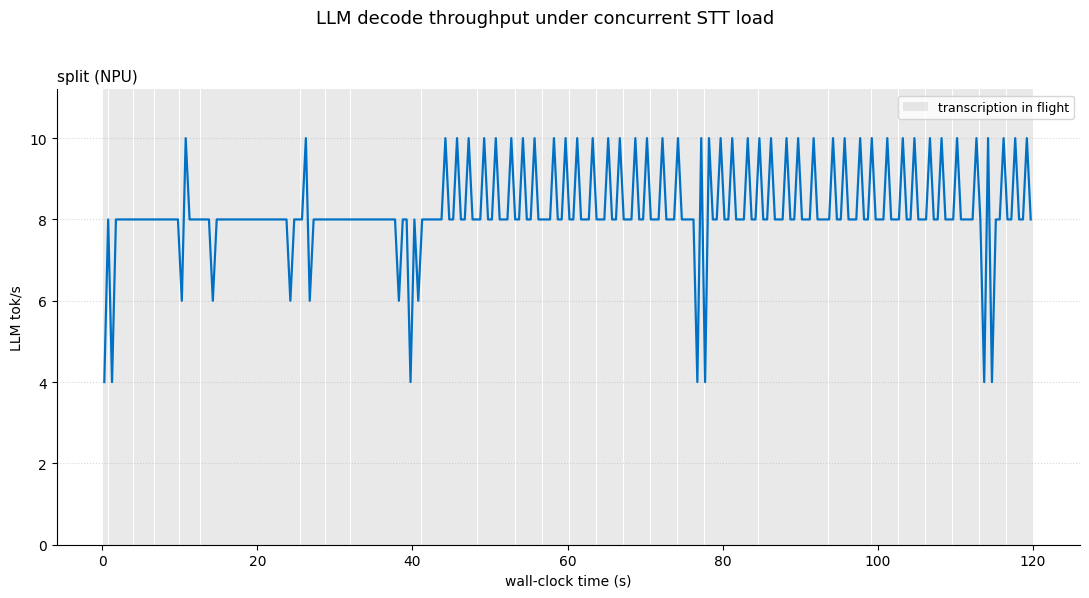

In [7]:
fig, axes = plotting.interference_timeline(runs, bin_s=0.5)
plt.show()

### Tail latency — the cost of contention

Empirical CDFs with p95/p99 marked. The shared config's curves lean right; that rightward
tail is the user-visible jitter a single-engine deployment pays under concurrency.

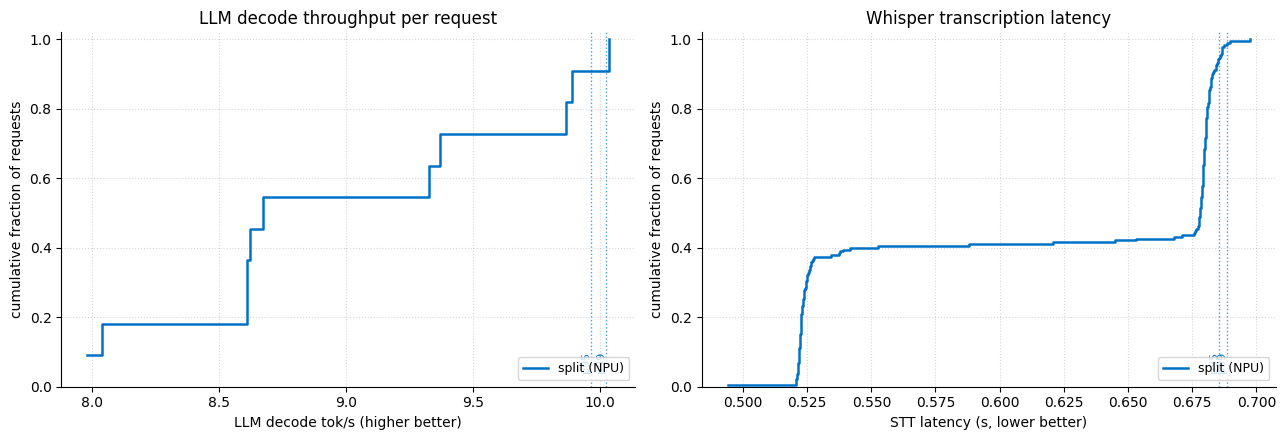

RTF skipped — set duration_s in data/audio.json to enable.


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
plotting.latency_cdf({r.label: r.llm_decode_tps() for r in runs},
                     ax=ax[0], xlabel='LLM decode tok/s (higher better)',
                     title='LLM decode throughput per request')
plotting.latency_cdf({r.label: r.stt_latency() for r in runs},
                     ax=ax[1], xlabel='STT latency (s, lower better)',
                     title='Whisper transcription latency')
plt.tight_layout(); plt.show()

# RTF only if at least one run has durations declared
rtf_series = {r.label: r.stt_rtf() for r in runs}
if any(v for v in rtf_series.values()):
    ax = plotting.latency_cdf(rtf_series, xlabel='STT real-time factor (RTF, <1 = faster than realtime)',
                              title='Whisper RTF under concurrent LLM load')
    ax.axvline(1.0, color='k', ls='--', lw=1.0, alpha=0.6)
    plt.tight_layout(); plt.show()
else:
    print('RTF skipped — set duration_s in data/audio.json to enable.')

### Combined throughput — two engines vs one

Total useful work the system sustained over the window. The split config does LLM and STT in
parallel on separate silicon, so it should clear more of both.

/home/mvsk/git/vlm-notebooks/bench/plotting.py:308: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(0, max(vals) * 1.18)


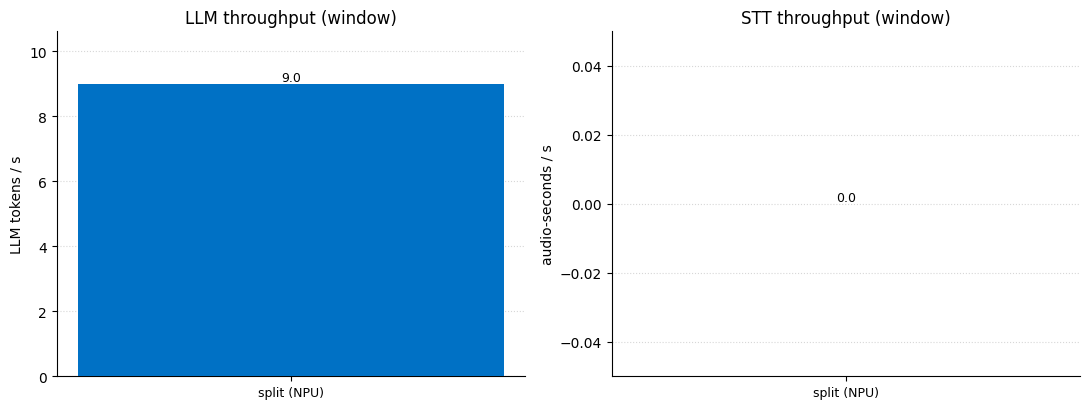

In [9]:
rows = [load.summary(r) for r in runs]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
plotting.metric_bars(rows, metric='llm_tokens_per_s', ylabel='LLM tokens / s',
                     ax=ax[0], title='LLM throughput (window)')
plotting.metric_bars(rows, metric='audio_s_per_s', ylabel='audio-seconds / s',
                     ax=ax[1], title='STT throughput (window)')
plt.tight_layout(); plt.show()

### iGPU memory budget

Peak iGPU-resident memory held by the **Whisper** process. In the split config it's ~0 — Whisper
is on the NPU and holds no DRM fd, so the iGPU's full budget stays with vLLM's KV cache. In the
shared config Whisper's weights/activations live in the same pool. (NPU device memory isn't
exposed via fdinfo the way iGPU is, so the split bar reads 0 by construction — that *is* the
point, not a measurement gap; the NPU's own RAM use shows up in RSS.)

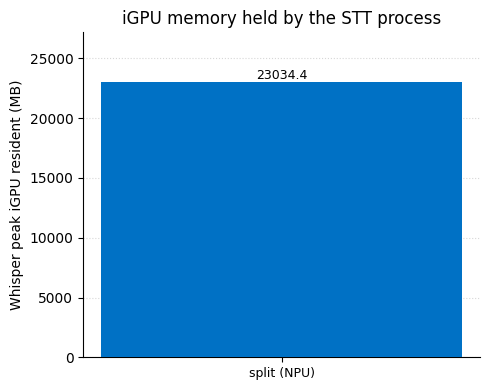

In [10]:
mem_rows = []
for r in runs:
    v = r.meta.get('whisper_peak_igpu_mb')
    mem_rows.append({'label': r.label, 'whisper_igpu_mb': (v or 0.0)})
ax = plotting.metric_bars(mem_rows, metric='whisper_igpu_mb',
                          ylabel='Whisper peak iGPU resident (MB)',
                          title='iGPU memory held by the STT process')
plt.tight_layout(); plt.show()

## Caveats (state these in the writeup)

- **Shared DRAM bandwidth.** NPU and iGPU are separate compute engines but feed off the same
  memory controller. The isolation this notebook shows is on *compute*; under extreme
  simultaneous load both engines still contend for DRAM bandwidth. Don't claim more than the
  data shows.
- **NPU memory isn't in fdinfo.** There's no `drm-resident-*` analog for `/dev/accel`, so the
  split config's Whisper-iGPU bar is 0 by construction. The NPU's RAM spill is captured in RSS,
  not as a device-memory figure.
- **Thermal.** Panther Lake throttles. Cool down between the two passes and, ideally, alternate
  run order across repeats so heat soak doesn't masquerade as a config difference.
- **Warmup.** If the first STT call's compile leaks into the window the split numbers look
  worse than reality — confirm the preflight warmup completed before the run cell.